<a href="https://colab.research.google.com/github/aawbed/kq-sales-order-intelligence/blob/main/notebooks/Model_3_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛫 Model 3: Isolation Forest Anomaly Detection
### KQ Water Bottling Plant (Project Kifaru) — Machine Learning Intelligence
---
**Objective:** Flag unusual transaction patterns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.ensemble import IsolationForest

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load Dataset from GitHub
We extract the historical transactional logs directly from the system's database CSV export.

In [2]:
dataset_url = "https://raw.githubusercontent.com/aawbed/kq-sales-order-intelligence/main/kq_historical_sales_2025_2026.csv"
df_orders = pd.read_csv(dataset_url)

df_orders['date'] = pd.to_datetime(df_orders['Date'])
df_orders = df_orders.rename(columns={
    'Order ID': 'order_id',
    'Customer Name': 'customer_name',
    'Account Type': 'account_type',
    'Product Name': 'product_name',
    'Quantity': 'quantity',
    'Unit Price (KSh)': 'unit_price_kes',
    'Total Amount (KSh)': 'total_amount_kes',
    'Total Litres': 'total_litres'
})

print(f"Dataset successfully loaded!\nTotal Records: {len(df_orders)}")
df_orders.head()

Dataset successfully loaded!
Total Records: 761


,order_id,Date,customer_name,account_type,product_name,quantity,unit_price_kes,total_amount_kes,total_litres,date
0,KQ-251,2026-03-19,Customer 15,Distributor,250ml Cups Case (48 Pack),40,960.0,38400.0,480.0,2026-03-19
1,KQ-251,2026-03-19,Customer 15,Distributor,10L Bulk Dispenser Box,12,900.0,10800.0,120.0,2026-03-19
2,KQ-252,2026-03-30,Customer 2,Corporate Client,Premium Glass 500ml (12 Pack),2,3600.0,7200.0,12.0,2026-03-30
3,KQ-252,2026-03-30,Customer 2,Corporate Client,Premium Glass 500ml (12 Pack),38,3600.0,136800.0,228.0,2026-03-30
4,KQ-252,2026-03-30,Customer 2,Corporate Client,Flavored Water 500ml Case (24 Pack),37,1440.0,53280.0,444.0,2026-03-30


## 2. Model Training & Evaluation

Total Orders Evaluated: 761
Flagged Anomalous Orders: 31



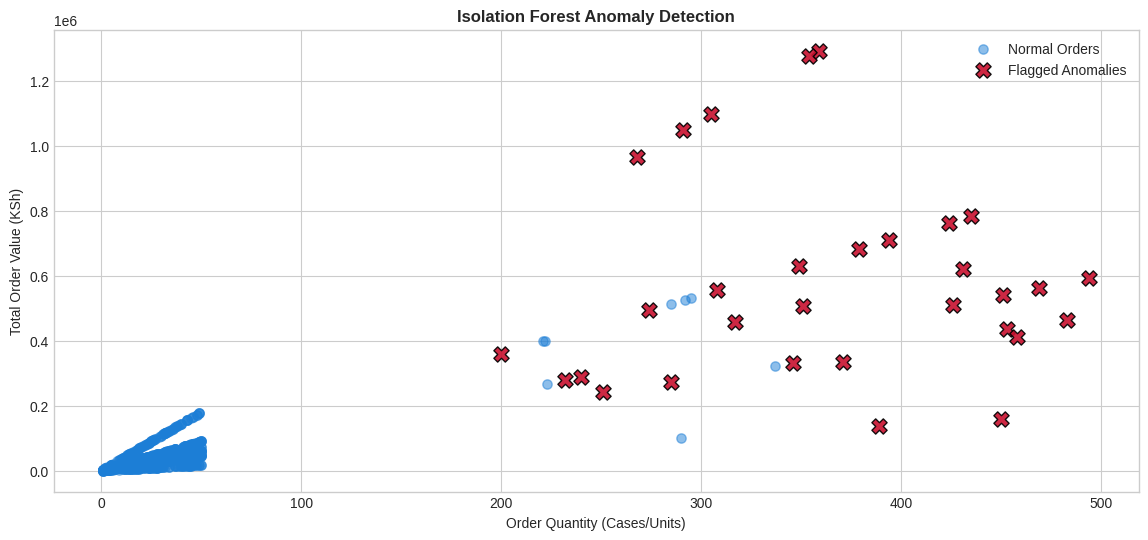


=== Top Flagged Anomalies ===


,order_id,date,customer_name,product_name,quantity,total_amount_kes,anomaly_score
47,KQ-269,2026-03-02,Customer 7,Premium Glass 500ml (12 Pack),359,1292400.0,-0.108252
74,KQ-278,2026-08-31,Customer 14,20L Dispenser Bottle,379,682200.0,-0.037292
75,KQ-278,2026-08-31,Customer 14,500ml Bottle Case (24 Pack),426,511200.0,-0.030468
85,KQ-281,2026-05-29,Customer 3,250ml Cups Case (48 Pack),453,434880.0,-0.090399
90,KQ-283,2026-07-07,Customer 5,500ml Bottle Case (24 Pack),451,541200.0,-0.043530


In [3]:
# Feature Engineering
cust_freq = df_orders.groupby('customer_name')['order_id'].transform('count')
df_orders['customer_order_freq'] = cust_freq
features = df_orders[['quantity', 'total_amount_kes', 'customer_order_freq']]

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.04, random_state=42)
df_orders['anomaly_pred'] = iso_forest.fit_predict(features)
df_orders['anomaly_score'] = iso_forest.decision_function(features)

df_orders['is_flagged'] = df_orders['anomaly_pred'] == -1
flagged_orders = df_orders[df_orders['is_flagged']]

print(f"Total Orders Evaluated: {len(df_orders)}")
print(f"Flagged Anomalous Orders: {len(flagged_orders)}\n")

# Plot
plt.figure(figsize=(14, 6))
plt.scatter(
    df_orders[~df_orders['is_flagged']]['quantity'],
    df_orders[~df_orders['is_flagged']]['total_amount_kes'],
    c='#1c7ed6', alpha=0.5, label='Normal Orders', s=45
)
plt.scatter(
    flagged_orders['quantity'],
    flagged_orders['total_amount_kes'],
    c='#c8102e', alpha=0.9, label='Flagged Anomalies', s=120, edgecolors='black', marker='X'
)

plt.title("Isolation Forest Anomaly Detection", fontweight='bold')
plt.xlabel("Order Quantity (Cases/Units)")
plt.ylabel("Total Order Value (KSh)")
plt.legend()
plt.show()

print("\n=== Top Flagged Anomalies ===")
display(flagged_orders[['order_id', 'date', 'customer_name', 'product_name', 'quantity', 'total_amount_kes', 'anomaly_score']].head())